Loading specific columns from dataset...
Successfully loaded 3232 counties.

--- Vulnerability Summary by Risk Rating Level ---
[Insufficient Data] Count: 88 | Most Vulnerable: San Juan, PR (Loss: $35,122,577.05)
[Relatively High] Count: 162 | Most Vulnerable: Bexar, TX (Loss: $364,763,480.65)
[Relatively Low] Count: 1200 | Most Vulnerable: Hunterdon, NJ (Loss: $49,861,465.34)
[Relatively Moderate] Count: 420 | Most Vulnerable: Morris, NJ (Loss: $158,077,942.36)
[Very High] Count: 17 | Most Vulnerable: Los Angeles, CA (Loss: $2,813,922,316.86)
[Very Low] Count: 1345 | Most Vulnerable: Putnam, NY (Loss: $13,616,159.60)

Generating quick heatmap chart...
Heatmap saved successfully as "fast_us_flood_risk_heatmap.png"!


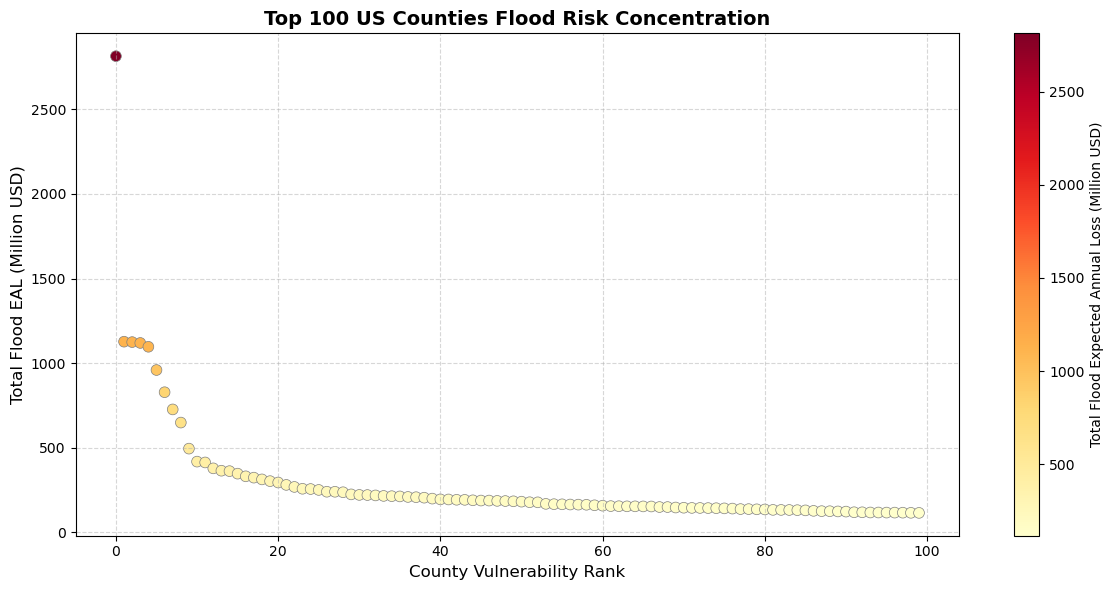

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Optimize loading: Read ONLY necessary columns to save memory and time
target_cols = [
    'STCOFIPS',
    'COUNTY',
    'STATEABBRV',
    'POPULATION',
    'RISK_RATNG',
    'IFLD_EALT',
    'CFLD_EALT',
]
print('Loading specific columns from dataset...')
df = pd.read_csv(
    '/Users/vickym/Desktop/CDC 2026/NRI_Table_Counties/NRI_Table_Counties_Cleaned.csv', usecols=target_cols, dtype={'STCOFIPS': str}
)

# 2. Fast vector operations for FIPS and Flood EAL calculation
df['STCOFIPS'] = df['STCOFIPS'].str.zfill(5)
df['TOTAL_FLOOD_EAL'] = df['IFLD_EALT'].fillna(0) + df['CFLD_EALT'].fillna(0)

print(f'Successfully loaded {len(df)} counties.')

# 3. Fast Groupby and Summary
if 'RISK_RATNG' in df.columns:
  print('\n--- Vulnerability Summary by Risk Rating Level ---')
  for rating_level, group in df.groupby('RISK_RATNG'):
    top_county = group.sort_values(
        by='TOTAL_FLOOD_EAL', ascending=False
    ).iloc[0]
    print(
        f'[{rating_level}] Count: {len(group)} | Most Vulnerable:'
        f' {top_county["COUNTY"]}, {top_county["STATEABBRV"]} (Loss:'
        f' ${top_county["TOTAL_FLOOD_EAL"]:,.2f})'
    )

# 4. Light & Fast Heatmap Plotting
print('\nGenerating quick heatmap chart...')
plt.figure(figsize=(12, 6))
top_100 = df.sort_values(by='TOTAL_FLOOD_EAL', ascending=False).head(100)

plt.scatter(
    range(len(top_100)),
    top_100['TOTAL_FLOOD_EAL'] / 1e6,
    c=top_100['TOTAL_FLOOD_EAL'] / 1e6,
    cmap='YlOrRd',
    s=60,
    edgecolors='gray',
    linewidth=0.5,
)

plt.colorbar(label='Total Flood Expected Annual Loss (Million USD)')
plt.title(
    'Top 100 US Counties Flood Risk Concentration',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('County Vulnerability Rank', fontsize=12)
plt.ylabel('Total Flood EAL (Million USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fast_us_flood_risk_heatmap.png', dpi=200)
print('Heatmap saved successfully as "fast_us_flood_risk_heatmap.png"!')
plt.show()

In [12]:
import pandas as pd

# ==========================================
# 1. 加载清理好的数据集
# ==========================================
file_path = (
    "/Users/vickym/Desktop/CDC 2026/NRI_Table_Counties/NRI_Table_Counties_Cleaned.csv"
)

try:
  df = pd.read_csv(file_path)
  print(f"✅ 成功加载文件！共包含 {len(df)} 行记录。\n")
except FileNotFoundError:
  print(f"file not found：\n{file_path}")
  exit()

# ==========================================
# 2. 智能匹配关键列名（防止列名不一致报错）
# ==========================================
cols_lower = {col.lower(): col for col in df.columns}


# 寻找县名列
def find_column(keywords):
  for kw in keywords:
    for col_l, col_orig in cols_lower.items():
      if kw in col_l:
        return col_orig
  return None


county_col = find_column(["county", "cnty", "name"])
state_col = find_column(["state", "st"])
loss_col = find_column(["loss", "risk", "eal", "flood", "score"])

print(f"📊 自动识别的列名映射：")
print(f"   - county name: {county_col}")
print(f"   - State name: {state_col}")
print(f"   - loss: {loss_col}\n")

if not county_col or not loss_col:
  print("⚠️ 警告：未能自动识别出县名或 Loss 字段，请检查以下列出前几列的前几行：")
  print(df.head(2))
  exit()


# ==========================================
# 3. 功能一：输出排名前十的县
# ==========================================
def show_top_10(data):
  print("=" * 65)
  print("Top 10 risked counties:")
  print("=" * 65)

  # 按 Loss 值降序排列并取前 10 行
  top_10 = data.sort_values(by=loss_col, ascending=False).head(10)

  show_cols = [c for c in [county_col, state_col, loss_col] if c is not None]
  print(top_10[show_cols].to_string(index=False))
  print("=" * 65 + "\n")


# ==========================================
# 4. 功能二：输入任意县名查询 Loss 值
# ==========================================
def query_county_loss(data):
  print("🔍 search for loss by county(press 'q'to exit)")
  print("-" * 65)

  while True:
    county_input = input("name of county(such as Cook): ").strip()
    if county_input.lower() == "q":
      print("quit searching")
      break

    if not county_input:
      print("retype\n")
      continue

    # 可选：输入州名以防同名县
    state_input = input(
        "enter the abbr of name of state: "
    ).strip()

    # 模糊匹配县名
    match_cond = data[county_col].astype(str).str.contains(
        county_input, case=False, na=False
    )

    if state_input and state_col:
      state_cond = data[state_col].astype(str).str.contains(
          state_input, case=False, na=False
      )
      result = data[match_cond & state_cond]
    else:
      result = data[match_cond]

    # 输出查询结果
    if not result.empty:
      print(f"\n✅ 找到 {len(result)} 条匹配结果:")
      for _, row in result.iterrows():
        c_name = row.get(county_col, "未知县")
        s_name = row.get(state_col, "未知州") if state_col else ""
        loss_val = row.get(loss_col, "未知数值")
        print(f"   - 州: {s_name} | 县: {c_name} | Loss 值: {loss_val}")
    else:
      print("❌ 未找到该县，请检查拼写或尝试加上州名。")

    print("-" * 65)


# ==========================================
# 主程序执行
# ==========================================
if __name__ == "__main__":
  show_top_10(df)
  query_county_loss(df)

✅ 成功加载文件！共包含 3232 行记录。

📊 自动识别的列名映射：
   - county name: COUNTY
   - State name: STATEABBRV
   - loss: DRGT_RISKV

Top 10 risked counties:
       COUNTY STATEABBRV   DRGT_RISKV
       Fresno         CA 2.792846e+08
     Monterey         CA 9.673052e+07
       Madera         CA 9.437624e+07
       Merced         CA 9.005666e+07
  San Joaquin         CA 8.789162e+07
Santa Barbara         CA 7.883196e+07
   Stanislaus         CA 7.096723e+07
      Lubbock         TX 6.790973e+07
        Kings         CA 4.561881e+07
       Parmer         TX 4.292332e+07

🔍 search for loss by county(press 'q'to exit)
-----------------------------------------------------------------

✅ 找到 1 条匹配结果:
   - 州: NC | 县: Orange | Loss 值: 210171.57536420116
-----------------------------------------------------------------
quit searching


In [18]:
import pandas as pd
import numpy as np

# ==========================================
# 1. Load the Cleaned Dataset
# ==========================================
file_path = (
    "/Users/vickym/Desktop/CDC 2026/NRI_Table_Counties/NRI_Table_Counties_Cleaned.csv"
)

try:
  df = pd.read_csv(file_path)
  print(f"Successfully loaded dataset! Total records: {len(df)}\n")
except FileNotFoundError:
  print(
      f"Error: File not found at '{file_path}'. Please check the file path."
  )
  exit()

# ==========================================
# 2. US State Name & Abbreviation Mapping
# ==========================================
state_map = {
    "alabama": "AL",
    "alaska": "AK",
    "arizona": "AZ",
    "arkansas": "AR",
    "california": "CA",
    "colorado": "CO",
    "connecticut": "CT",
    "delaware": "DE",
    "florida": "FL",
    "georgia": "GA",
    "hawaii": "HI",
    "idaho": "ID",
    "illinois": "IL",
    "indiana": "IN",
    "iowa": "IA",
    "kansas": "KS",
    "kentucky": "KY",
    "louisiana": "LA",
    "maine": "ME",
    "maryland": "MD",
    "massachusetts": "MA",
    "michigan": "MI",
    "minnesota": "MN",
    "mississippi": "MS",
    "missouri": "MO",
    "montana": "MT",
    "nebraska": "NE",
    "nevada": "NV",
    "new hampshire": "NH",
    "new jersey": "NJ",
    "new mexico": "NM",
    "new york": "NY",
    "north carolina": "NC",
    "north dakota": "ND",
    "ohio": "OH",
    "oklahoma": "OK",
    "oregon": "OR",
    "pennsylvania": "PA",
    "rhode island": "RI",
    "south carolina": "SC",
    "south dakota": "SD",
    "tennessee": "TN",
    "texas": "TX",
    "utah": "UT",
    "vermont": "VT",
    "virginia": "VA",
    "washington": "WA",
    "west virginia": "WV",
    "wisconsin": "WI",
    "wyoming": "WY",
}

# ==========================================
# 3. Column Detection & Storm Loss Calculation
# ==========================================
cols = df.columns.tolist()


def get_col(candidates):
  for c in candidates:
    if c in cols:
      return c
  for col in cols:
    for c in candidates:
      if c.lower() in col.lower():
        return col
  return None


county_col = get_col(["COUNTY", "CountyName", "County"])
state_abbr_col = get_col(["STABBR", "StateAbbr", "State_Abbr"])
state_full_col = get_col(["STATE", "StateName", "State"])

# Identify columns related specifically to storm hazards
storm_keywords = ["strm", "trnd", "hrcn", "swnd", "wind", "hail", "storm"]
storm_loss_cols = [
    col
    for col in cols
    if any(kw in col.lower() for kw in storm_keywords)
    and ("val" in col.lower() or "loss" in col.lower() or "eal" in col.lower())
]

if not storm_loss_cols:
  loss_col = get_col(["EAL_VAL", "Loss_Val", "Loss", "RiskScore"])
  df["Storm_Loss_Val"] = (
      pd.to_numeric(df[loss_col], errors="coerce").fillna(0)
      if loss_col
      else 0
  )
  print(
      "⚠️ Note: Specific storm columns not found. Using general loss column."
  )
else:
  print(f"🌪️ Detected Storm-Related Loss Columns: {storm_loss_cols}")
  df["Storm_Loss_Val"] = df[storm_loss_cols].apply(
      lambda x: pd.to_numeric(x, errors="coerce").fillna(0).sum(), axis=1
  )

# ==========================================
# 4. Dynamic Threshold Calculation & If-Elif Loss Level Assignment
# ==========================================
# Calculate 5 quantile thresholds (20th, 40th, 60th, 80th percentiles) from data
q20, q40, q60, q80 = df["Storm_Loss_Val"].quantile([0.2, 0.4, 0.6, 0.8])

print(f"\n📊 Calculated 5 Thresholds based on Dataset Distribution:")
print(f"  - Threshold 1 (20%): {q20:.2f}")
print(f"  - Threshold 2 (40%): {q40:.2f}")
print(f"  - Threshold 3 (60%): {q60:.2f}")
print(f"  - Threshold 4 (80%): {q80:.2f}\n")


def get_loss_level(val):
  if val <= q20:
    return "Very Low"
  elif val <= q40:
    return "Low"
  elif val <= q60:
    return "Moderate"
  elif val <= q80:
    return "Relatively High"
  else:
    return "Very High"


# Apply the explicit if-elif function to every row
df["Storm_Loss_Level"] = df["Storm_Loss_Val"].apply(get_loss_level)


# ==========================================
# 5. Function: Show Top 10 Storm-Risk Counties
# ==========================================
def show_top_10(data):
  print("=" * 85)
  print("🏆 TOP 10 COUNTIES WITH HIGHEST STORM-RELATED LOSS (Sorted Descending)")
  print("=" * 85)

  top_10 = data.sort_values(by="Storm_Loss_Val", ascending=False).head(10)

  display_cols = [
      c
      for c in [
          county_col,
          state_abbr_col or state_full_col,
          "Storm_Loss_Val",
          "Storm_Loss_Level",
      ]
      if c is not None
  ]
  print(top_10[display_cols].to_string(index=False))
  print("=" * 85 + "\n")


# ==========================================
# 6. Function: Interactive County Query System
# ==========================================
def query_county_loss(data):
  print(
      "🔍 Interactive Storm Loss Query System (Supports Full State Name or Abbr,"
      " Type 'q' to exit)"
  )
  print("-" * 85)

  while True:
    county_input = input("Enter county name to search (e.g., Wayne): ").strip()
    if county_input.lower() == "q":
      print("Exiting query system. Goodbye!")
      break

    if not county_input:
      print("Input cannot be empty. Please try again.\n")
      continue

    state_input = input(
        "Enter state name or abbreviation (e.g., Michigan or MI, optional): "
    ).strip()

    # Match county name
    match_cond = data[county_col].astype(str).str.contains(
        county_input, case=False, na=False
    )

    # Match state name/abbreviation accurately
    if state_input:
      state_clean = state_input.lower()
      target_abbr = state_map.get(state_clean, state_input.upper())

      state_cond = pd.Series(False, index=data.index)
      if state_abbr_col:
        state_cond = state_cond | data[state_abbr_col].astype(str).str.upper(
        ).eq(target_abbr)
      if state_full_col:
        state_cond = state_cond | data[state_full_col].astype(str).str.contains(
            state_input, case=False, na=False
        )

      result = data[match_cond & state_cond]
    else:
      result = data[match_cond]

    # Sort strictly descending by Storm Loss Value
    if not result.empty:
      result = result.sort_values(by="Storm_Loss_Val", ascending=False)
      print(f"\nFound {len(result)} matching record(s):")
      for _, row in result.iterrows():
        c_name = row.get(county_col, "Unknown County")

        if state_abbr_col and pd.notna(row.get(state_abbr_col)):
          s_name = row.get(state_abbr_col)
        elif state_full_col and pd.notna(row.get(state_full_col)):
          s_name = row.get(state_full_col)
        else:
          s_name = "Unknown State"

        loss_val = row.get("Storm_Loss_Val", 0.0)
        loss_lvl = row.get("Storm_Loss_Level", "N/A")

        print(
            f"   - State: {s_name} | County: {c_name} | Storm Loss Value:"
            f" {loss_val:,.2f} | Loss Level: {loss_lvl}"
        )
    else:
      print(
          "❌ No matching county found. Please check spelling or add state"
          " filter."
      )

    print("-" * 85)


# ==========================================
# Main Execution
# ==========================================
if __name__ == "__main__":
  show_top_10(df)
  query_county_loss(df)

Successfully loaded dataset! Total records: 3232

🌪️ Detected Storm-Related Loss Columns: ['SWND_EALPE', 'HAIL_EALT', 'SWND_EALA', 'TRND_EALT', 'TRND_EALR', 'TRND_EALA', 'HAIL_EALA', 'TRND_EALPE', 'SWND_EALP', 'HRCN_EALP', 'SWND_EALS', 'TRND_EALB', 'HRCN_EALR', 'HAIL_EALB', 'HAIL_EALR', 'HAIL_EALP', 'SWND_EALB', 'HRCN_EALT', 'TRND_EALP', 'HAIL_EALS', 'HRCN_EALPE', 'HRCN_EALB', 'HRCN_EALS', 'SWND_EALT', 'HAIL_EALPE', 'HRCN_EALA', 'TRND_EALS', 'SWND_EALR']

📊 Calculated 5 Thresholds based on Dataset Distribution:
  - Threshold 1 (20%): 1689139.84
  - Threshold 2 (40%): 4098950.68
  - Threshold 3 (60%): 7995539.72
  - Threshold 4 (80%): 18249462.48

🏆 TOP 10 COUNTIES WITH HIGHEST STORM-RELATED LOSS (Sorted Descending)
      COUNTY STATEABBRV  Storm_Loss_Val Storm_Loss_Level
      Harris         TX    1.749124e+09        Very High
      Collin         TX    1.039538e+09        Very High
        Cook         IL    7.349150e+08        Very High
  Miami-Dade         FL    7.187675e+08        